# PCA through Singular Value Decomposition

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn import decomposition
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score

In [3]:
import numpy as np

# Defined 3 points in 2D-space:
X = np.array([[2, 1],
              [4, 3],
              [0, 0]], dtype=float)

# 1) Center the data (important for PCA/SVD)
X_centered = X - X.mean(axis=0)

# 2) Calculate the covariance matrix R (2x2)
# rowvar=False => columns are variables (x and y)
R = np.cov(X_centered, rowvar=False)

# 3) SVD decomposition of covariance matrix
U, D, Vt = np.linalg.svd(R)  # Vt is V transpose
u1 = U[:, 0]                 # first basis vector
u2 = U[:, 1]                 # second basis vector

print("X:\n", X)
print("X_centered:\n", X_centered)
print("Covariance matrix R:\n", R)
print("U (basis vectors):\n", U)
print("D (singular values):\n", D)
print("u1 =", u1)
print("u2 =", u2)

X:
 [[2. 1.]
 [4. 3.]
 [0. 0.]]
X_centered:
 [[ 0.         -0.33333333]
 [ 2.          1.66666667]
 [-2.         -1.33333333]]
Covariance matrix R:
 [[4.         3.        ]
 [3.         2.33333333]]
U (basis vectors):
 [[-0.79612934 -0.60512649]
 [-0.60512649  0.79612934]]
D (singular values):
 [6.28025695 0.05307638]
u1 = [-0.79612934 -0.60512649]
u2 = [-0.60512649  0.79612934]


In [4]:
# 4) Coordinates in the new orthonormal basis
# Projection of centered points onto the new basis U
Z = X_centered @ U
print("Coordinates in new basis (Z):\n", Z)

# 5) Approximation using only the first component (rank-1 approximation)
Z1 = Z.copy()
Z1[:, 1] = 0                  # keep only component along u1
X_approx = Z1 @ U.T + X.mean(axis=0)

print("Rank-1 approximation of X:\n", X_approx)

Coordinates in new basis (Z):
 [[ 0.20170883 -0.26537645]
 [-2.60080284  0.11662926]
 [ 2.39909401  0.14874719]]
Rank-1 approximation of X:
 [[ 1.83941368  1.21127398]
 [ 4.07057546  2.90714802]
 [ 0.09001086 -0.118422  ]]


In [5]:
# 6) Reconstruct the original data from full coordinates (should match X)
X_reconstructed = Z @ U.T + X.mean(axis=0)
print("Reconstructed X:\n", X_reconstructed)

# Optional: numerical check
print("Reconstruction error:", np.max(np.abs(X - X_reconstructed)))

Reconstructed X:
 [[ 2.0000000e+00  1.0000000e+00]
 [ 4.0000000e+00  3.0000000e+00]
 [-4.4408921e-16  0.0000000e+00]]
Reconstruction error: 4.440892098500626e-16


# PCA on Iris data

In [6]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0]


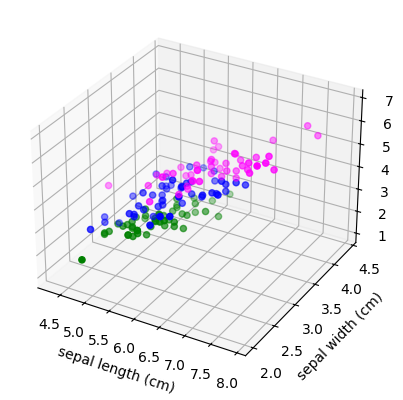

In [7]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
print(iris.feature_names)
print(X[:5])
print(y[:10])
import matplotlib.pyplot as plt
axes1 = plt.axes(projection='3d')

axes1.scatter3D(X[y==0,0], X[y==0,1], X[y==0,2], color='green')
axes1.scatter3D(X[y==1,0], X[y==1,1], X[y==1,2], color='blue')
axes1.scatter3D(X[y==2,0], X[y==2,1], X[y==2,2], color='magenta')

axes1.set_xlabel(iris.feature_names[0])
axes1.set_ylabel(iris.feature_names[1])
axes1.set_zlabel(iris.feature_names[2])

plt.show()


Covariance matrix:
[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]
[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


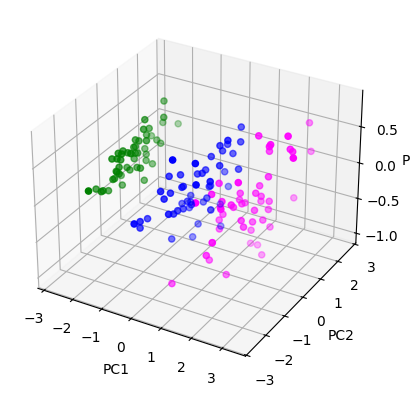

In [8]:
# Pre-processing is an important step, you can try either StandardScaler (zero mean, unit variance of features)
# or MinMaxScaler (to interval from 0 to 1)
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
Xscaler = StandardScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
scaler = StandardScaler()
Xpp = scaler.fit_transform(X)

pca = decomposition.PCA(n_components=3)
Xpca = pca.fit_transform(Xpp)

print("Covariance matrix:")
print(pca.get_covariance())
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2 = plt.axes(projection='3d')

axes2.scatter3D(Xpca[y==0,0], Xpca[y==0,1], Xpca[y==0,2], color='green')
axes2.scatter3D(Xpca[y==1,0], Xpca[y==1,1], Xpca[y==1,2], color='blue')
axes2.scatter3D(Xpca[y==2,0], Xpca[y==2,1], Xpca[y==2,2], color='magenta')

axes2.set_xlabel("PC1")
axes2.set_ylabel("PC2")
axes2.set_zlabel("PC3")

plt.show()


In [9]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.72962445 0.22850762 0.03668922]
Total explained variance:
0.9948212908928451


In [10]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

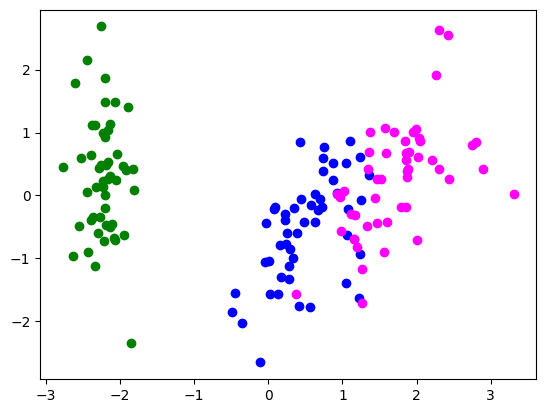

In [12]:
# Plot the principal components in 2D, mark different targets in color
plt.scatter(Xpca[y==0,0], Xpca[y==0,1], color='green')
plt.scatter(Xpca[y==1,0], Xpca[y==1,1], color='blue')
plt.scatter(Xpca[y==2,0], Xpca[y==2,1], color='magenta')
plt.show()

# KNN classifier

Accuracy (4D original): 0.9777777777777777


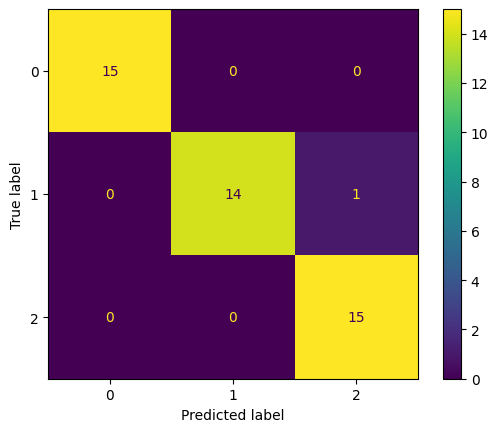

In [25]:
# Import train_test_split as in last PC lab, split X (original) into train and test, train KNN classifier on full 4-dimensional X

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)

knn1 = KNeighborsClassifier(n_neighbors=3)
knn1.fit(X_train, y_train)

y_pred = knn1.predict(X_test)

print("Accuracy (4D original):", accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


Accuracy (PCA 2D): 0.8888888888888888


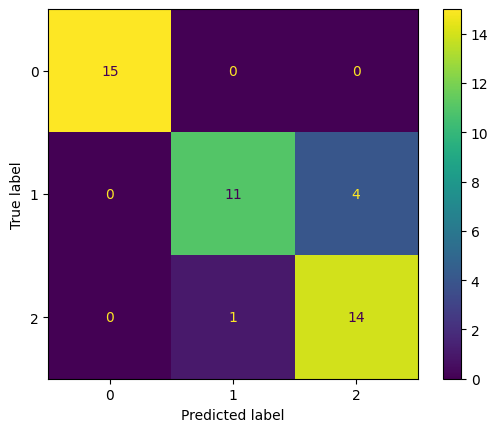

In [26]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns). 
# Compare the results with full dataset
scaler = StandardScaler()
Xpp = scaler.fit_transform(X)

pca2 = decomposition.PCA(n_components=2)
Xpca2 = pca2.fit_transform(Xpp)

X_train, X_test, y_train, y_test = train_test_split(
    Xpca2, y, test_size=0.3, stratify=y
)

knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train, y_train)

y_pred2 = knn2.predict(X_test)

print("Accuracy (PCA 2D):", accuracy_score(y_test, y_pred2))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred2)
plt.show()

Accuracy (2D original): 0.6888888888888889


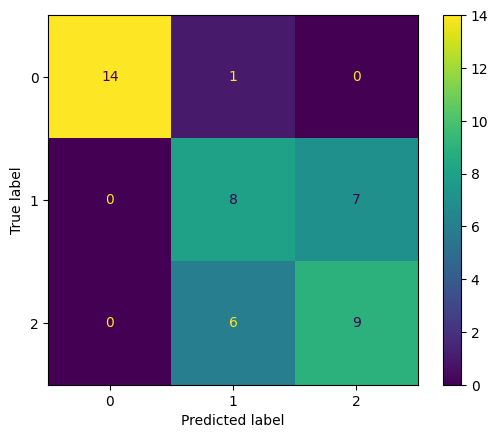

In [28]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)
X2 = X[:, :2]

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.3, stratify=y
)

knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)

y_pred3 = knn3.predict(X_test)

print("Accuracy (2D original):", accuracy_score(y_test, y_pred3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred3)
plt.show()